# `01-intro.ipynb`
- Langgraph 는 "흐름 제어"가 핵심
- 모든 노드가 공유하는 `State`

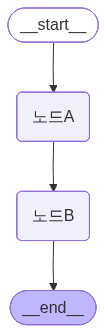

In [9]:
# Tiny Graph
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# 1. State (각 노드마다 사용할 데이터들 집합 -> 메세지 히스토리도 포함)
# {'text': 'abcd'}
class MyState(TypedDict):
    text: str


# 2. Node를 만든다
def node_a(state: MyState):
    new_text = state['text'] + '-> A노드 통과 '
    return {'text': new_text} 


def node_b(state: MyState):
    new_text = state['text'] + '-> B노드 통과'
    return {'text': new_text} 


# 3. Node - Edge 연결한다
graph = StateGraph(MyState)  # 새로운 상태그래프. MyState를 모두 공유하기

graph.add_node('노드A', node_a)  # 새로운 노드 등록. 앞은 부를 이름, 뒤는 함수 이름
graph.add_node('노드B', node_b)

graph.add_edge(START, '노드A')    # graph.set_entry_point('노드A')
graph.add_edge('노드A', '노드B')  # 앞과 뒤를 잇는다.
graph.add_edge('노드B', END)      # graph.set_finish_point('노드B')

# 4. 그래프를 만든다(compile).
app = graph.compile()
app

In [10]:
app.invoke({'text': '아주 작은 그래프'})

{'text': '아주 작은 그래프-> A노드 통과 -> B노드 통과'}

## 조건 라우터

In [12]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# State 정의
class SystemState(TypedDict):  
    message: str
    is_ok: bool
    next_step: str

# {'message': 'blah blah', 'is_ok': True, 'next_step': '계속 진행 하세요' }

In [ ]:
# {'message': '모두 좋아'}

# Node 만들기
def process_message(state: SystemState):
    print('---메세지처리---', state)

    msg = state['message']
    if ('error' in msg.lower()) or ('에러' in msg):
        result = False
    else:
        result = True
    
    # node 에서 전체 state를 return 할 필요 없음. 
    # 바뀐것만 return 하면 state의 바뀌지 않은 부분은 그대로 다음 노드로 넘어감
    return {'is_ok': result}  


# {'message': 문제없음', "is_ok": True}
def normal_node(state: SystemState):
    print('---문제없음노드---', state)
    return {'next_step': '문제 없음. 계속 진행'}  # 여기도 바뀌는 부분만 return


def error_node(state: SystemState):
    print('---에러발생노드---', state)
    return {'next_step': '에러 발생. 삐용삐용'}

In [ ]:
# 라우터 (노드 아님 -> 절대 state 건들지 않기! 다음 node 판단에 활용할 값만 return)
def router(state: SystemState):
    if state['is_ok']:
        return '괜춘'
    else:
        return '안괜춘'

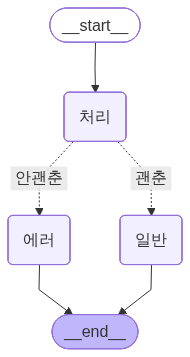

In [36]:
# 합치기
graph = StateGraph(SystemState)

graph.add_node('처리', process_message)
graph.add_node('일반', normal_node)
graph.add_node('에러', error_node)

graph.add_edge(START, '처리')

graph.add_conditional_edges(
    '처리',  # 분기 시작 지점
    router,  # 분기를 담당할 함수
    {
        '괜춘': '일반',  # router 함수의 결과 -> 다음 노드 이름
        '안괜춘': '에러'
    }
)
graph.add_edge('일반', END)
graph.add_edge('에러', END)

app = graph.compile()
app

In [ ]:
app.invoke({'message': '에러 발생'})


---메세지처리--- {'message': '에러 발생'}
---에러발생노드--- {'message': '에러 발생', 'is_ok': False}


{'message': '에러 발생', 'is_ok': False, 'next_step': '에러 발생. 삐용삐용'}